# Import Rideshare Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib

Uncomment this cell to run (1-4 min):

Reccomend that you have 16gb storage on your computer to run this

In [ ]:
# df = pd.read_csv("<path_to_your_rideshare_data_file>.csv")

Select only the cells we want and store as `share`: 

In [29]:
master_share = df[['Trip ID', 'Trip Start Timestamp', 'Trip End Timestamp', 'Trip Seconds', 'Trip Miles', 'Percent Time Chicago', 'Percent Distance Chicago', 'Pickup Census Tract', 'Dropoff Census Tract', 'Fare', 'Tip', 'Additional Charges','Trip Total', 'Pickup Centroid Latitude', 'Pickup Centroid Longitude','Dropoff Centroid Latitude','Dropoff Centroid Longitude']]

share = master_share

In [30]:
# Should have 31146361 rows
len(share)

31146361

First on the cleaning agenda:
    There are some percentage (time and distance) that are greater than 100.
    Let's see how many of those there are and decide what to do about those.

2 options:
    a) delete them
    b) Check if lat and long start and end are both in chicago, if so keep, else delete

Convert percntages into a usable datatype, int (20-30s):

In [31]:
share['Int Percent Time Chicago'] = (
    share['Percent Time Chicago'].str.replace("%", "").str.replace(",", "")
).astype(int)

share['Int Percent Distance Chicago'] = (
    share['Percent Distance Chicago'].str.replace("%", "").str.replace(",", "")
).astype(int)

In [32]:
time_over = (share['Int Percent Time Chicago'] > 100).sum()
time_in = (share['Int Percent Time Chicago'] == 100).sum()

dist_over = (share['Int Percent Distance Chicago'] > 100).sum()
dist_in = (share['Int Percent Distance Chicago'] == 100).sum()

print(f"{time_over} rows have a percentage of time over 100%, compared to {time_in} that are normal\nso unrealistic percentages make up {round(time_over  * 100 / (time_over + time_in), 3)}% of the dataset")

print(f"{dist_over} rows have a percentage of distance over 100%, compared to {dist_in} that are normal\nso unrealistic percentages make up {round(dist_over  * 100 / (dist_over + dist_in), 3)}% of the dataset")

23732 rows have a percentage of time over 100%, compared to 31122629 that are normal
so unrealistic percentages make up 0.076% of the dataset
15727 rows have a percentage of distance over 100%, compared to 31130634 that are normal
so unrealistic percentages make up 0.05% of the dataset


Because the percentage of the data that has unrealistic time or duration percentages is relativley low, for simplicity's sake we're just going to remove those rows from the dataset for this round of exploration.

In [33]:
before_len = len(share)
print(f"Before removing rows with unlikely time/distance percentages, we have {before_len} rows in the dataset")

#  Save a copy of the data before removing rows, in case we want to come back to it
share_with_perc = share

Before removing rows with unlikely time/distance percentages, we have 31146361 rows in the dataset


(15-20s)

In [34]:
share = share[share['Int Percent Time Chicago'] == 100]
share = share[share['Int Percent Distance Chicago'] == 100]

after_len = len(share)
print(f"We are left with {after_len} rows in the dataset, having removed {before_len - after_len}")

We are left with 31108563 rows in the dataset, having removed 37798


Remove percentage time and percentage distance cols as that's no longer relevant.  Let's take a look at the data.

In [53]:
share = share[['Trip ID', 'Trip Start Timestamp', 'Trip End Timestamp', 'Trip Seconds', 'Trip Miles', 'Pickup Census Tract', 'Dropoff Census Tract', 'Fare', 'Tip', 'Additional Charges','Trip Total', 'Pickup Centroid Latitude', 'Pickup Centroid Longitude','Dropoff Centroid Latitude','Dropoff Centroid Longitude']]
share_before_nan_drop = share

Replace string "NaN" to true null `np.nan` (10-15s)

In [54]:
share = share.replace('NaN', np.nan)

In [56]:
share = share.dropna()

In [79]:
clean_share = share
print(f"After basic cleaning, we are left with {len(share)} rows")

After basic cleaning, we are left with 19264104 rows


## Paring Down

At this point I would consider the  most basic level of cleaning done.  Next we do exploration and figure out how to dramatically par down our data while still preserving the nature of the data

Potential paths:

- Acccording to google, 2-3 decimal places is 1.1km to 111m precision. We definitley do not want to be more granular than 3 decimals, but curious to see how much dropping from 3 to 2 decimal places reduces the start/stop pairs we need to make api calls for.
- How much census tract data is missing? (JK after the NaN cleaning step we should only have complete data)
- How much data is in 1 week? 1 month?
- Should we randomly select 100,000 rows ??

### Removing unnecessarily expensive rides

Total trip cost to float

In [57]:
share['Int Total'] = (
    share['Trip Total'].str.replace("$", "").str.replace(",", "")
).astype(float)

Can we exclude extremely expensive rides?

In [77]:
share.sort_values(by = 'Int Total', ascending=False).head()

,Trip ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Fare,Tip,Additional Charges,Trip Total,Pickup Centroid Latitude,Pickup Centroid Longitude,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Int Total
25044305,0710a2aeec4c6faa62793f315b7bdf5457570a2b,03/14/2025 02:30:00 PM,03/14/2025 06:15:00 PM,"13,430",86.0,1.703169e+10,1.703165e+10,$585,$0,$1.23,$586.23,41.754846,-87.610169,41.762247,-87.732059,586.23
2484772,8b4c6086a0ec35f2a39d31178ec9389ddc380f9f,11/28/2025 10:45:00 AM,11/28/2025 01:30:00 PM,"9,408",87.6,1.703132e+10,1.703132e+10,$497.5,$50,$2.73,$550.23,41.877406,-87.621972,41.877406,-87.621972,550.23
18161625,a321b3407d1d3bae31450b4013d1ef420e8cf99d,05/31/2025 12:45:00 PM,05/31/2025 02:45:00 PM,"7,318",77.5,1.703142e+10,1.703198e+10,$467.5,$0,$7.77,$475.27,41.783460,-87.593537,41.979071,-87.903040,475.27
29804420,0950a702a6715faf736ff19f8ba610ab6e5ceb63,01/18/2025 12:45:00 AM,01/18/2025 02:15:00 AM,"5,470",57.2,1.703116e+10,1.703116e+10,$375,$30,$1.23,$406.23,41.942700,-87.731002,41.942700,-87.731002,406.23
19813775,17a2bda0037912519cac630581a849eaba46314a,05/13/2025 06:00:00 PM,05/13/2025 07:45:00 PM,"6,397",41.7,1.703123e+10,1.703123e+10,$402.5,$0,$1.23,$403.73,41.891754,-87.718671,41.891754,-87.718671,403.73


np.int64(7796)

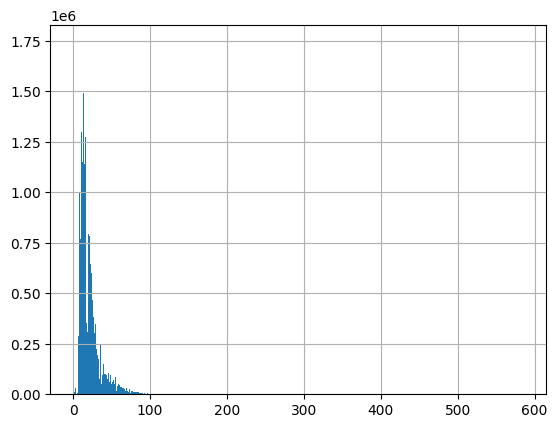

In [ ]:
share['Int Total'].hist(bins = 500)

Number of rides that are over $100:

In [76]:
(share['Int Total'] > 100).sum()

np.int64(62351)